In [41]:
!pip install bambi
import pymc as pm
import pandas as pd
import arviz as az
import bambi as bmb
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
data_url = "https://raw.githubusercontent.com/NAU-SHERC-ResearchCapacityCore/Python-Coding-Series-1/refs/heads/main/data/iris.csv"
data = pd.read_csv(data_url)
print(data.head())

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


Here is an example of building a model with PyMC.

In [43]:
with pm.Model() as model:
    x = data[["Sepal_Width", "Sepal_Length"]]
    y = data["Petal_Width"]
    sigma = pm.HalfStudentT("sigma", nu=4, sigma=10)
    intercept = pm.Normal("Intercept", 0, sigma=10)
    sepal_width = pm.Normal("Sepal_Width", 0, sigma=10)
    sepal_length = pm.Normal("Sepal_Length", 0, sigma=10)
    mu = pm.Deterministic("mu", intercept + sepal_width*x["Sepal_Width"] + sepal_length*x["Sepal_Length"])
    likelihood = pm.Normal("y", mu=mu, sigma=sigma, observed=y)
    result = pm.sample()

Output()

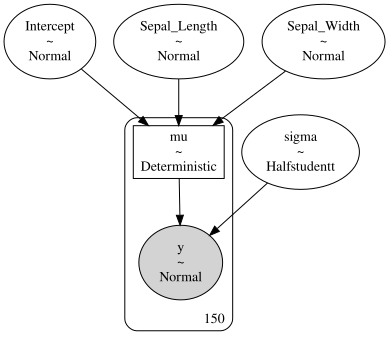

In [44]:
model.to_graphviz()

In [45]:
az.summary(result, var_names="~mu")

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.573,0.332,-2.230,-0.996,0.012,0.009,768.0,897.0,1.0
Sepal_Length,0.722,0.038,0.653,0.796,0.001,0.001,952.0,1085.0,1.0
Sepal_Width,-0.474,0.074,-0.608,-0.336,0.002,0.002,1051.0,1130.0,1.0
sigma,0.392,0.024,0.351,0.439,0.001,0.001,1286.0,1158.0,1.0


Here is an example of adding another term. It is always fine to add all of your variables and parameters individually. However, it can be tedious if you have a large model.

In [46]:
with pm.Model() as model:
    x = data[["Sepal_Width", "Sepal_Length"]]
    y = data["Petal_Width"]
    sigma = pm.HalfStudentT("sigma", nu=4, sigma=10)
    intercept = pm.Normal("Intercept", 0, sigma=10)
    sepal_width = pm.Normal("Sepal_Width", 0, sigma=10)
    sepal_length = pm.Normal("Sepal_Length", 0, sigma=10)
    mu = pm.Deterministic("mu", intercept + sepal_width*x["Sepal_Width"] + sepal_length*x["Sepal_Length"])
    likelihood = pm.Normal("y", mu=mu, sigma=sigma, observed=y)
    # result = pm.sample()

We can add additional terms more easily using a design matrix and matrix algebra using numpy. PyMC offers utilities (not used here) for making this easier, such as "coords".

In [47]:
import numpy as np
with pm.Model() as pm_model:
    x = data[["Sepal_Width", "Sepal_Length", "Petal_Width"]].to_numpy()
    y = data["Petal_Length"].to_numpy()[..., np.newaxis]
    sigma = pm.HalfStudentT("sigma", nu=4, sigma=10)
    intercept = pm.Normal("Intercept", 0, sigma=10, size=(1, 1))
    slope = pm.Normal("slope", 0, sigma=10, size=(x.shape[1], 1))
    mu = pm.Deterministic("mu", intercept + x @ slope)
    likelihood = pm.Normal("y", mu=mu, sigma=sigma, observed=y)
    result = pm.sample()

Output()

Note that the components of slope are not labeled.

array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Intercept'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'slope'}>]], dtype=object)

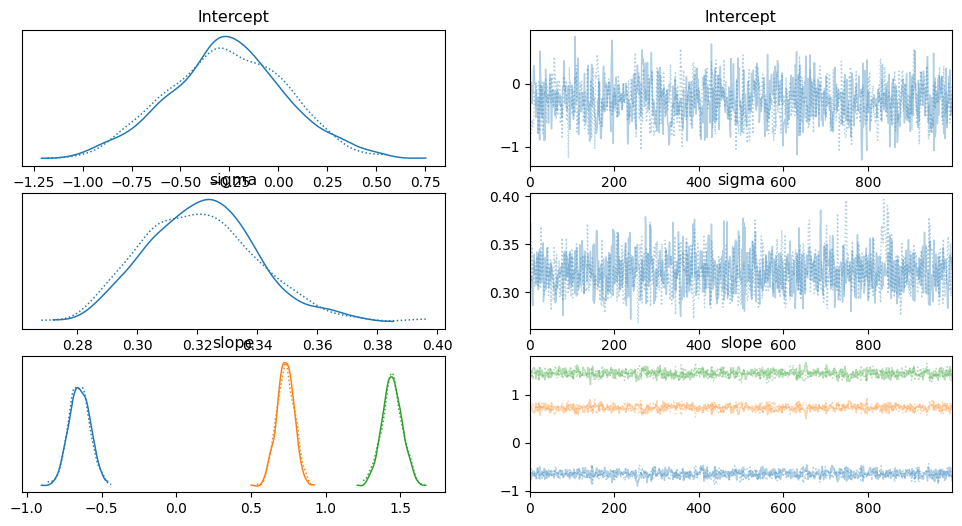

In [48]:
az.plot_trace(result, var_names="~mu")